In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/gokulrajkmv/unemployment-in-india/Unemployment_Rate_upto_11_2020.csv
/kaggle/input/datasets/gokulrajkmv/unemployment-in-india/Unemployment in India.csv


In [4]:
# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/gokulrajkmv/unemployment-in-india/Unemployment_Rate_upto_11_2020.csv')

In [5]:
# Clean column names
df.columns = df.columns.str.strip()

print(df.head())

           Region         Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-01-2020         M                             5.48   
1  Andhra Pradesh   29-02-2020         M                             5.83   
2  Andhra Pradesh   31-03-2020         M                             5.79   
3  Andhra Pradesh   30-04-2020         M                            20.51   
4  Andhra Pradesh   31-05-2020         M                            17.43   

   Estimated Employed  Estimated Labour Participation Rate (%) Region.1  \
0            16635535                                    41.02    South   
1            16545652                                    40.90    South   
2            15881197                                    39.18    South   
3            11336911                                    33.10    South   
4            12988845                                    36.46    South   

   longitude  latitude  
0    15.9129     79.74  
1    15.9129     79.74  
2    15.912

In [8]:
# Convert Date to datetime format (pecifically telling Python that the day comes first)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Create a new column for 'Month' to make grouping easier
df['Month'] = df['Date'].dt.month_name()

# checking the first few rows to make sure the dates look correct
print(df[['Date']].head())

        Date
0 2020-01-31
1 2020-02-29
2 2020-03-31
3 2020-04-30
4 2020-05-31


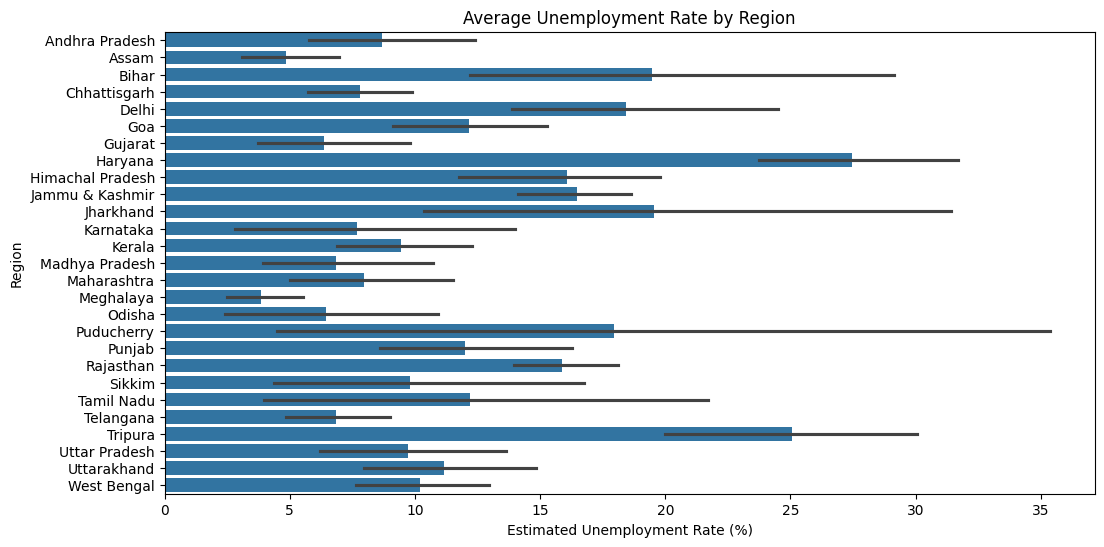

In [7]:
plt.figure(figsize=(12, 6))
plt.title("Average Unemployment Rate by Region")
sns.barplot(x='Estimated Unemployment Rate (%)', y='Region', data=df)
plt.show()

In [10]:
print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude', 'Month'],
      dtype='object')


In [16]:
# Renaming 'Region.1' to 'Area' for better clarity
df = df.rename(columns={'Region.1': 'Area'})

In [14]:
# Sunburst plot to show unemployment by Region (State) and Region.1 (Area type)
figure = px.sunburst(df, 
                     path=["Region", "Area"], 
                     values="Estimated Unemployment Rate (%)", 
                     width=700, height=700, 
                     color_continuous_scale="RdYlGn",
                     title="Unemployment Rate in India (State vs Area)")
figure.show()

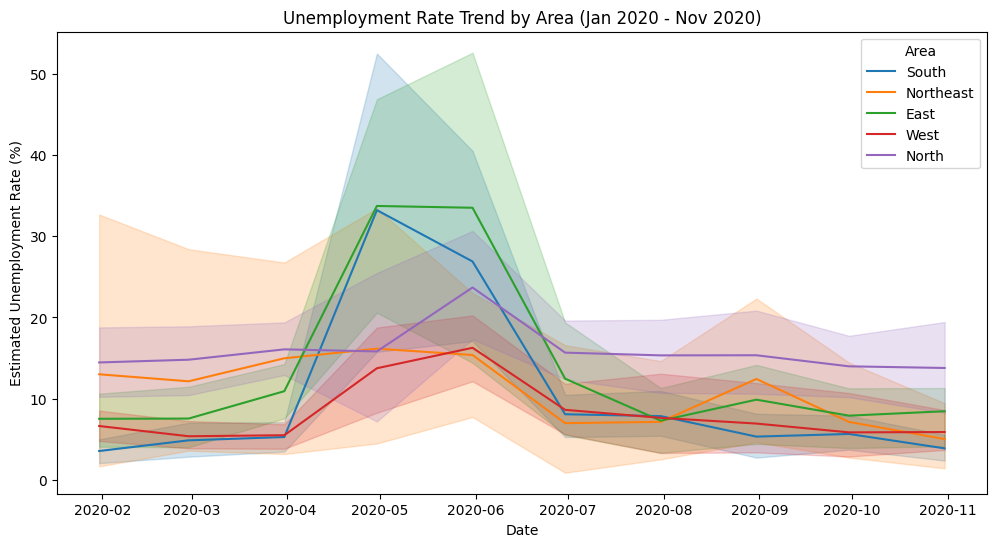

In [17]:
# running the line plot again using the new 'Area' name
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Date', y='Estimated Unemployment Rate (%)', hue='Area')
plt.title('Unemployment Rate Trend by Area (Jan 2020 - Nov 2020)')
plt.show()

Analysis shows a significant surge in unemployment rates across all regions in India starting April 2020, coinciding with the COVID-19 national lockdown. The North and East regions showed particularly high volatility.